# Retail Sales Performance & Profitability Analysis

## Business Problem

A retail company wants to understand why profitability is inconsistent despite strong sales performance.

This project analyzes sales transactions to identify:
- High and low performing products
- Regional performance
- Discount impact on profitability
- Customer purchasing patterns

The goal is to provide actionable business recommendations using SQL, Python, Excel and Power BI.

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Profiling
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Business Insights

In [5]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

## Data Profiling

Before performing any analysis, the dataset is inspected to understand its structure, data types, missing values and basic statistics.

In [7]:
# Dataset Preview

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
#Dataset shape

df.shape

(9994, 21)

In [9]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [10]:
# Summary Statistics

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning

The first step in data cleaning is to identify missing values.

Missing values can affect calculations, visualizations and business insights if not handled appropriately.

In [11]:
# Check missing values

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Observation

- No missing values were found in any column.
- Therefore, no action was required for handling missing data.
- The dataset will now be checked for duplicate records and other data quality issues.

In [13]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

### Observation

- No duplicate rows were found in the dataset.
- Therefore, no duplicate records needed to be removed.
- The dataset will now be checked for data type consistency.

In [17]:
# Convert date columns

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

### Observation

- Converted `Order Date` from string to datetime.
- Converted `Ship Date` from string to datetime.
- This enables time-based analysis such as monthly trends, yearly comparisons, and shipping duration calculations.

In [21]:
#Checking Data Types 
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

### Observation

- Verified that all business metrics are stored in appropriate numeric formats.
- Confirmed that date columns are stored as datetime objects.
- The dataset is now ready for feature engineering and exploratory data analysis.

# Feature Engineering

Feature engineering involves creating new variables from existing data.

These new features help uncover deeper business insights and make the data more suitable for analysis and visualization.

The following features were created to support trend analysis, profitability analysis, and logistics performance.

### Feature 1: Order Year

The Order Year column was created to enable yearly sales and profit analysis.

This feature helps identify long-term business growth trends.

In [23]:
#Order Year

df["Order Year"]=df["Order Date"].dt.year

### Feature 2: Order Month

The Order Month column was created to analyze monthly sales patterns and seasonality.

Using month names instead of month numbers makes visualizations easier to interpret.

In [88]:
#Order Month

df["Order Month"]=df["Order Date"].dt.month_name()

### Feature 3: Order Quarter

The Order Quarter column enables quarterly performance analysis.

Businesses often review revenue and profit on a quarterly basis for strategic planning.

In [29]:
#Order Quarter

df["Order Quarter"]=df["Order Date"].dt.quarter

### Feature 4: Shipping Days

Shipping Days measures the number of days taken to deliver an order.

This feature helps evaluate delivery performance and can be used to investigate whether longer shipping times affect customer satisfaction or profitability.

In [27]:
#Shipping Days

df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

### Feature 5: Profit Margin (%)

Profit Margin represents the percentage of revenue retained as profit.

This metric provides a better measure of profitability than profit alone because it considers the relationship between sales and profit.

In [28]:
#Profit Margin

df["Profit Margin"]=(df["Profit"]/df["Sales"])*100

### Feature 6: Month Number

The Month Number feature was created to preserve the chronological order of months during time-based analysis.

Month names are stored as text, which causes them to be sorted alphabetically (e.g., April, August, December). By creating a numeric month column (1–12), monthly trends can be displayed in the correct calendar order for accurate analysis and visualization.

In [92]:
#Month Number

df["Month Number"] = df["Order Date"].dt.month

## Feature Engineering Summary

The following business features were successfully created:

- Order Year
- Order Month
- Order Quarter
- Shipping Days
- Profit Margin (%)
- Month Number

These features will be used throughout the analysis to identify sales trends, shipping performance, seasonal patterns, and overall business profitability.

# Exploratory Data Analysis (EDA)

EDA is performed to identify trends, patterns and business opportunities within the sales data.

Each analysis focuses on answering a specific business question and concludes with actionable business recommendations.

## Business Question 1

Which product category generates the highest sales and profit?

In [35]:
category_summary=df.groupby("Category")[["Sales","Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


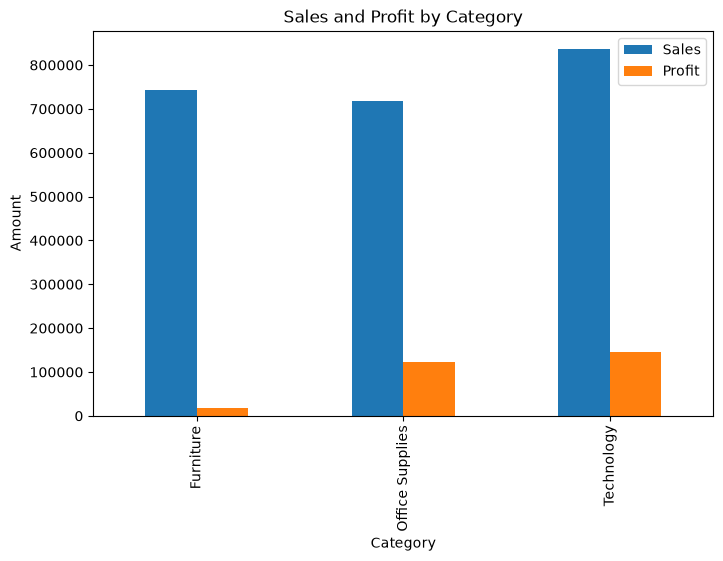

In [36]:
category_summary.plot(kind="bar", figsize=(8,5))

plt.title("Sales and Profit by Category")
plt.ylabel("Amount")
plt.show()

### Observation

Technology generated the highest overall profit, while Furniture generated comparatively lower profit despite strong sales.

### Business Insight

High sales do not always translate into high profitability.

The Furniture category appears to have lower profit margins compared to Technology.

### Recommendation

Increase marketing investment in high-margin categories while reviewing pricing and discount strategies for lower-margin categories.

## Business Question 2

### Which states generate the highest profit?

Understanding state-wise profitability helps identify the company's strongest and weakest markets.

This analysis supports decisions related to regional expansion, resource allocation, and marketing investments.

In [38]:
state_summary=df.groupby("State")["Profit"].sum().sort_values(ascending=False)
state_summary

State
California              76381.3871
New York                74038.5486
Washington              33402.6517
Michigan                24463.1876
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1023
Nebraska                 2037.0942
Montana                  1833.3285
South Carolina           1769.0566
New Hampshire 

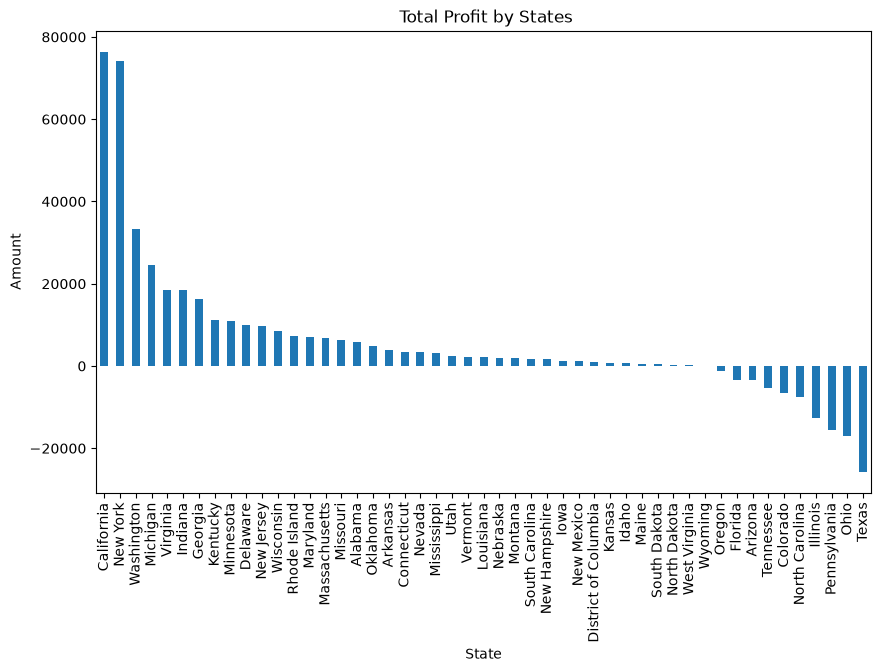

In [43]:
state_summary.plot(kind="bar",figsize=(10,6))
plt.title(" Total Profit by States")
plt.ylabel("Amount")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.show()

### Observation

California generated the highest total profit, while Texas recorded the lowest overall profit among all states.

### Business Insight

The large variation in profitability across states suggests that regional factors such as customer demand, pricing strategies, competition, or operational costs may significantly influence business performance.

### Recommendation

Increase marketing investment in high-performing states such as California while analyzing customer behavior, pricing strategies, and product preferences in these markets. Apply successful practices where appropriate to improve performance in lower-profit states like Texas.

## Business Question 3

### Which products generate high sales but low profit?

High sales do not always translate into high profitability.

This analysis aims to identify products that generate significant revenue but contribute relatively little profit, helping the business review pricing, discount strategies, and product performance.

In [51]:
product_summary = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

top_products=product_summary.head(10)

top_products

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03


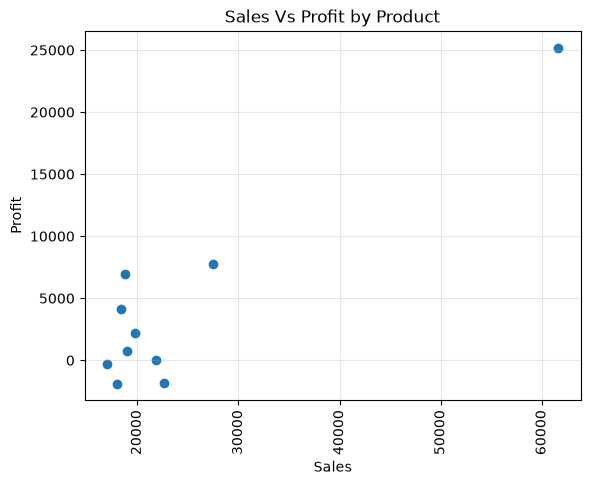

In [65]:
plt.scatter(top_products["Sales"], 
            top_products["Profit"])

plt.title("Sales Vs Profit by Product")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.show()

### Observation

One product generated exceptionally high sales and profit compared to all other products. Several products achieved relatively high sales but generated very low or even negative profit, while only a few products maintained both high sales and strong profitability.

### Business Insight

The variation between sales and profit suggests that revenue alone is not a reliable indicator of business performance. Differences in profit margins, discount strategies, product costs, and pricing policies may be affecting profitability.

### Recommendation

Increase marketing investment in products that consistently generate both high sales and high profit. For products with high sales but low or negative profit, investigate pricing, discount levels, supplier costs, and operational expenses before making further marketing investments.

## Business Question 4

### Does increasing discount reduce profitability?

Discounts are commonly used to increase sales and attract customers. However, excessive discounting may reduce overall profitability.

This analysis aims to evaluate the relationship between discount levels and profit to determine whether the current discount strategy is sustainable.

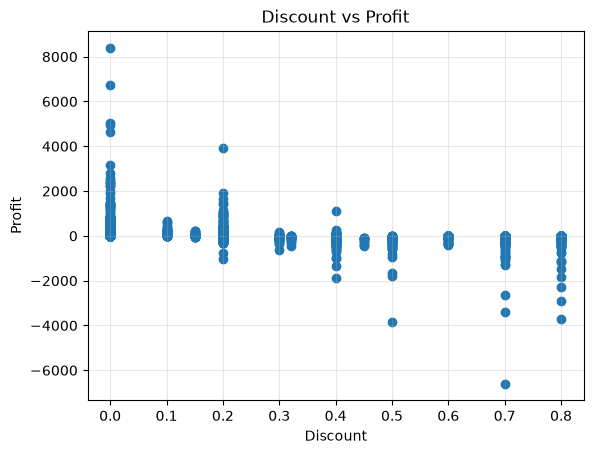

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

In [66]:
plt.scatter(
    df["Discount"],
    df["Profit"]
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(alpha=0.3)

plt.show()


discount_summary=(df.groupby("Discount")["Profit"].mean().sort_index())

discount_summary

### Observation

The analysis indicates an inverse relationship between discount and profit. As discount levels increase, profitability generally decreases, with many high-discount transactions resulting in negative profit.

### Business Insight

Higher discounts may increase sales volume, but excessive discounting can significantly reduce profit margins. If the selling price approaches or falls below the total cost, the business may incur losses despite generating revenue.

### Recommendation

Identify the maximum discount level that maintains profitability. Analyze discount effectiveness by product, category, and state to develop targeted pricing strategies rather than applying uniform discounts across all products.

## Business Question 5

### Which customer segment contributes the most to revenue and profit?

Customer segments contribute differently to business performance.

This analysis aims to identify the most valuable customer segment based on total sales and profit, helping the business allocate marketing resources more effectively and improve customer retention.

In [73]:
segment_summary=(df.groupby("Segment")
                 [["Sales","Profit"]]
                 .sum()
                 .sort_values(by="Sales",ascending=False)
                 )
segment_summary

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


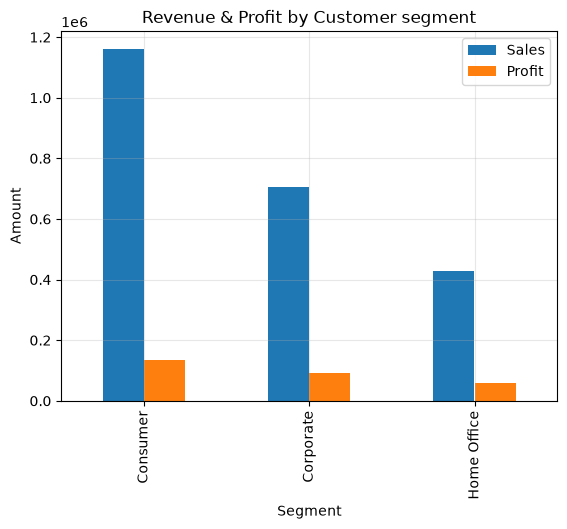

In [74]:
segment_summary.plot(kind="bar")
plt.title("Revenue & Profit by Customer segment")
plt.xlabel("Segment")
plt.ylabel("Amount")
plt.grid(alpha=0.3)
plt.xticks(rotation=90)
plt.show()

### Observation

The Consumer segment generated the highest total sales and profit, followed by Corporate, while the Home Office segment contributed the lowest sales and profit. Overall, sales and profit show a positive relationship across all three customer segments.

### Business Insight

The Consumer segment contributes the largest share of both sales and profit, making it the company's most valuable customer segment. The lower contribution from the Home Office segment suggests an opportunity to improve customer engagement and sales performance in that market.

### Recommendation

Continue investing in the Consumer segment through targeted marketing and retention campaigns, as it contributes the highest revenue and profit. At the same time, analyze the purchasing behavior of Home Office customers to identify opportunities for improving sales and profitability in that segment.

## Business Question 6

### How do monthly sales and profit change over time?

Analyzing monthly sales and profit trends helps identify seasonality, peak business periods, and potential slow months.

These insights support inventory planning, marketing campaigns, and revenue forecasting.

In [102]:
monthly_summary=(df.groupby(["Month Number","Order Month"])
                 [["Sales","Profit"]].sum()
                 .reset_index()
                .sort_values("Month Number")
                                           )
monthly_summary

,Month Number,Order Month,Sales,Profit
0,1,January,94924.8356,9134.4461
1,2,February,59751.2514,10294.6107
2,3,March,205005.4888,28594.6872
3,4,April,137762.1286,11587.4363
4,5,May,155028.8117,22411.3078
5,6,June,152718.6793,21285.7954
6,7,July,147238.0970,13832.6648
7,8,August,159044.0630,21776.9384
8,9,September,307649.9457,36857.4753
9,10,October,200322.9847,31784.0413


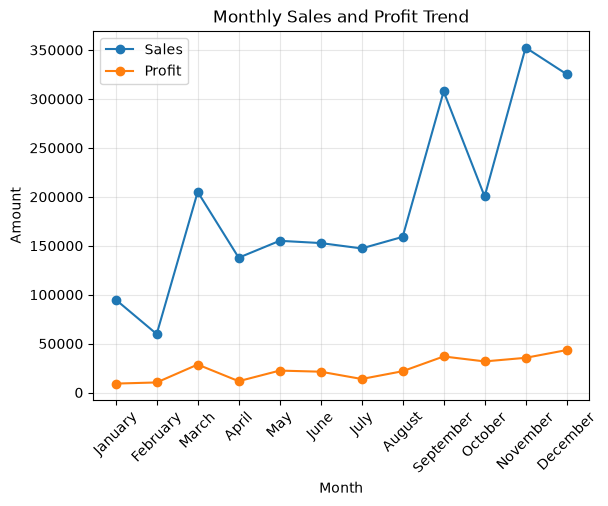

In [108]:
plt.plot(
    monthly_summary["Order Month"],
    monthly_summary["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_summary["Order Month"],
    monthly_summary["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Observation

Monthly sales and profit fluctuate throughout the year, indicating seasonal business patterns. Sales increase significantly during September, November, and December, with November recording the highest sales. Profit follows a similar trend, reaching its highest level in December despite a slight decline in sales compared to November.

### Business Insight

The business experiences strong seasonality, with the final quarter (October–December) generating the highest sales and profit. This suggests increased customer demand during the festive or holiday season. Although November achieved the highest sales, December generated higher profit, indicating stronger profit margins or more effective pricing strategies during that month.

### Recommendation

The company should increase inventory, staffing, and marketing efforts before the peak sales season to maximize revenue opportunities. Additionally, management should analyze the pricing and promotional strategies used in December to understand why profitability was higher and apply those successful practices in other months where appropriate.

## Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables.

This analysis helps identify how Sales, Profit, Discount, and Quantity are related and supports business insights with statistical evidence.

In [111]:
corr_data=df[["Sales","Profit","Discount","Quantity"]]

correlation=corr_data.corr()

correlation

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


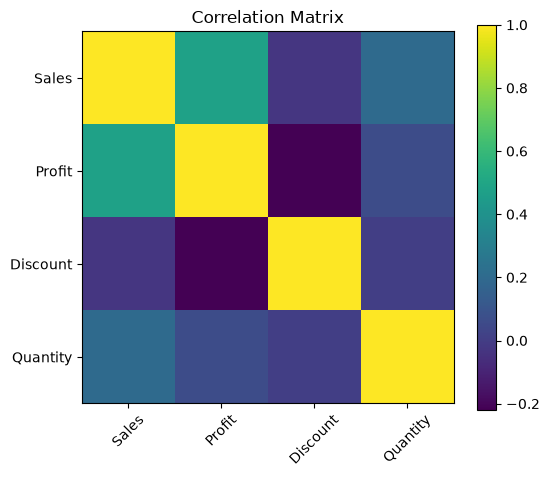

In [116]:
plt.figure(figsize=(6,5))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

### Observation

Sales and Profit show a positive correlation, indicating that higher sales generally contribute to higher profit.

Discount has a negative correlation with Profit, suggesting that higher discounts are associated with lower profitability.

Quantity has a weak positive relationship with Sales and Profit.

### Business Insight

The correlation analysis supports the findings from the previous visualizations. While increasing sales generally improves profitability, excessive discounting negatively affects profit margins. Quantity alone is not a strong indicator of profitability, highlighting the importance of pricing and discount strategies.

### Recommendation

Continue focusing on revenue growth while maintaining healthy profit margins. Optimize discount strategies to avoid unnecessary profit loss and evaluate pricing decisions using both sales volume and profitability metrics.